# RECOVAR — demo

Three parts:

1. **Labeled benchmark** — run the classifier on a labeled test set and plot the ROC/AUC.
2. **Single 40 s window** — score one window over the P arrival of a real earthquake from a MiniSEED file.
3. **Continuous scoring** — slide across the whole MiniSEED file and plot the score over time.

Parts 2–3 use the helpers in `mseed_demo/mseed_predictor.py` and the committed
`data/test.mseed` (450 s of KO.DKL..HH? around the M6.1 Bigadiç–Balıkesir 2025
earthquake).

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import sys
import numpy as np
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime

sys.path.insert(0, "mseed_demo")   # MiniSEED helpers

from recovar.representation_learning_models import RepresentationLearningMultipleAutoencoder
from recovar.classifier_models import ClassifierMultipleAutoencoder
from sklearn.metrics import roc_curve, roc_auc_score

from mseed_predictor import (
    load_traces, load_scorer, score_window, score_file,
    preprocess_stream, INNER_S,
)

In [2]:
# Configuration
MODEL_PATH = "models/representation_cross_covariances.h5"

# Part 1 — labeled test set
TEST_DATA_PATH  = "data/X_test_1280sample.npy"
TEST_LABEL_PATH = "data/Y_test_1280sample.npy"

# Parts 2-3 — real MiniSEED
MSEED_PATH = "data/test.mseed"
STEP_S     = 10.0   # sliding-window step (s)
THRESHOLD  = 0.5    # detection threshold

## Part 1 — Labeled benchmark (ROC / AUC)

The classifier wraps the representation-learning model and returns an earthquake
probability per sample. We run it on the labeled test set and plot the ROC curve.

In [3]:
X_test = np.load(TEST_DATA_PATH)
Y_test = np.load(TEST_LABEL_PATH)
print(f"Test data:  {X_test.shape}")
print(f"Test labels: {Y_test.shape}")

model = RepresentationLearningMultipleAutoencoder(
    name="rep_learning_autoencoder_ensemble", input_noise_std=1e-6, eps=1e-27)
model.compile()
model(X_test)
model.load_weights(MODEL_PATH)
classifier = ClassifierMultipleAutoencoder(model)

Test data:  (1280, 3000, 3)
Test labels: (1280,)


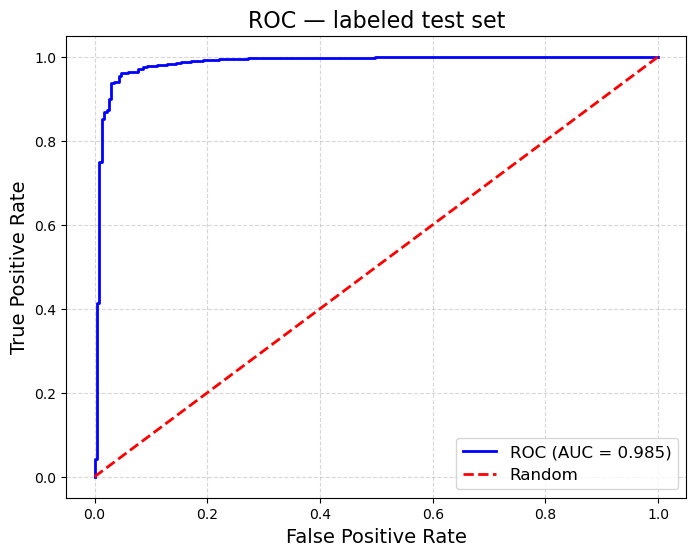

In [4]:
earthquake_scores = classifier(X_test)

fpr, tpr, _ = roc_curve(Y_test, earthquake_scores)
auc = roc_auc_score(Y_test, earthquake_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC — labeled test set", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Part 2 — Single 40 s window on real MiniSEED

One 40 s window over the P arrival of the M6.1 Bigadiç earthquake. The window is
bandpassed (1–20 Hz), cropped to the inner 30 s, demeaned + L2-normalized, and
scored. We plot the three components of that window next to the score.

In [5]:
traces = load_traces(MSEED_PATH)
scorer = load_scorer(MODEL_PATH)

# Window start over the P arrival (window covers 40 s; inner 30 s is scored)
t_win = UTCDateTime("2025-08-10T16:53:34.96")
score = score_window(traces, scorer, t_win)
print(f"Single 40 s window starting {t_win}")
print(f"RECOVAR earthquake probability: {score:.4f}")

Single 40 s window starting 2025-08-10T16:53:34.960000Z
RECOVAR earthquake probability: 0.9225


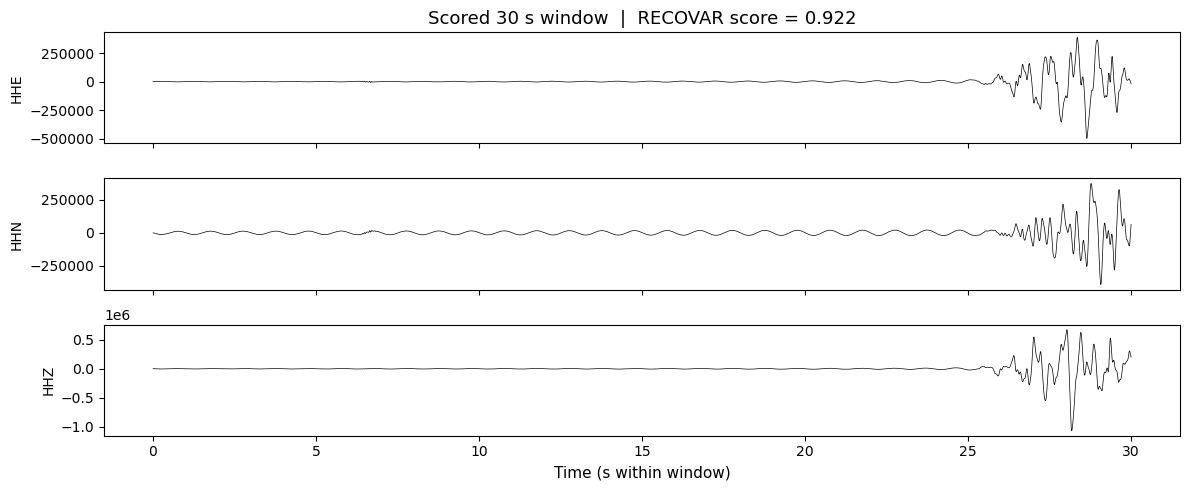

In [6]:
# Plot the inner 30 s of the scored window (bandpassed), per component
st_win = preprocess_stream(read(MSEED_PATH)).slice(t_win + 5, t_win + 35)

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for ax, tr in zip(axes, sorted(st_win, key=lambda t: t.stats.channel)):
    t = np.arange(tr.stats.npts) / tr.stats.sampling_rate
    ax.plot(t, tr.data, "k", linewidth=0.5)
    ax.set_ylabel(tr.stats.channel, fontsize=10)
axes[-1].set_xlabel("Time (s within window)", fontsize=11)
axes[0].set_title(f"Scored 30 s window  |  RECOVAR score = {score:.3f}", fontsize=13)
plt.tight_layout()
plt.show()

## Part 3 — Continuous scoring over the whole file

Slide a window across the full 450 s and plot the score over time. The score should
rise sharply at the P arrival and decay through the coda.

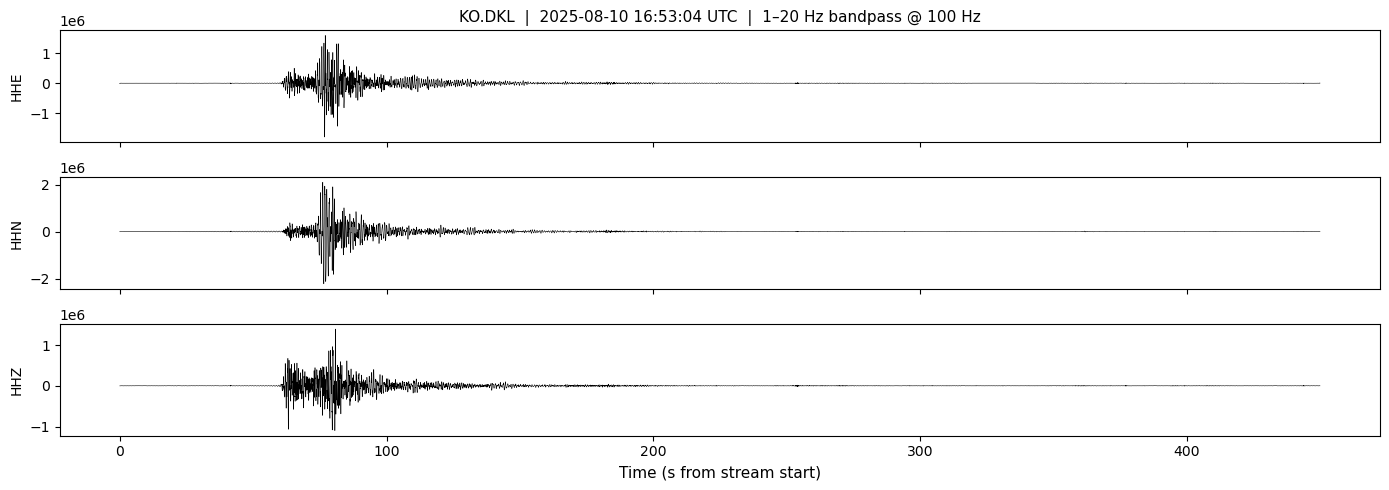

In [7]:
st_raw = read(MSEED_PATH)
t0     = st_raw[0].stats.starttime
st     = preprocess_stream(st_raw)

fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
for ax, tr in zip(axes, sorted(st, key=lambda t: t.stats.channel)):
    t = np.arange(tr.stats.npts) / tr.stats.sampling_rate
    ax.plot(t, tr.data, "k", linewidth=0.4)
    ax.set_ylabel(tr.stats.channel, fontsize=10)
axes[-1].set_xlabel("Time (s from stream start)", fontsize=11)
axes[0].set_title(
    f"{st[0].stats.network}.{st[0].stats.station}  |  "
    f"{t0.strftime('%Y-%m-%d %H:%M:%S')} UTC  |  1–20 Hz bandpass @ 100 Hz",
    fontsize=11)
plt.tight_layout()
plt.show()

Scored 41 windows  (step=10.0s, inner window=30s)
Score range: 0.0368 – 0.9225


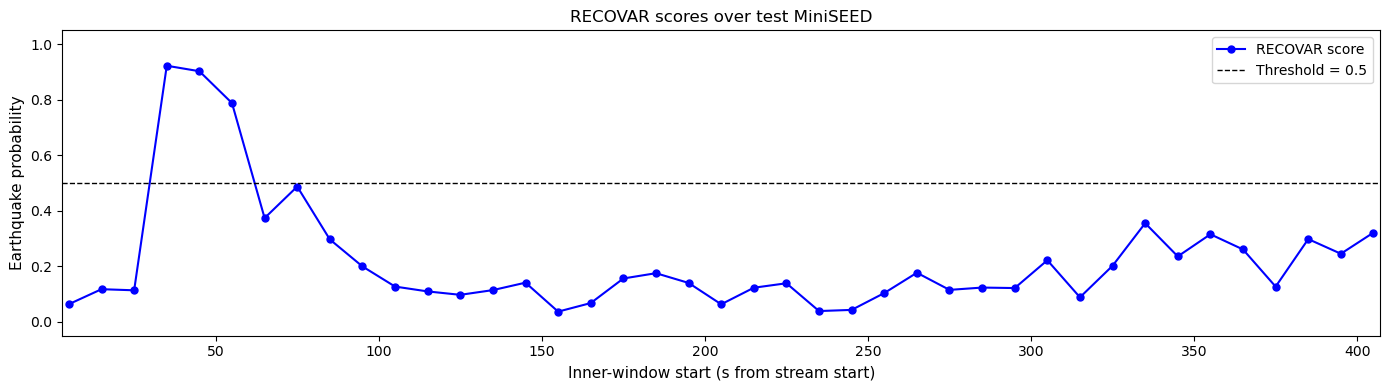

In [8]:
results     = list(score_file(MSEED_PATH, MODEL_PATH, step_s=STEP_S))
inner_times = [float(r[1] - t0) for r in results]
scores      = [r[2] for r in results]

print(f"Scored {len(results)} windows  (step={STEP_S}s, inner window={INNER_S:.0f}s)")
print(f"Score range: {min(scores):.4f} – {max(scores):.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(inner_times, scores, "b-o", linewidth=1.5, markersize=5, label="RECOVAR score")
ax.axhline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"Threshold = {THRESHOLD}")
ax.set_xlim(inner_times[0] - 2, inner_times[-1] + 2)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Inner-window start (s from stream start)", fontsize=11)
ax.set_ylabel("Earthquake probability", fontsize=11)
ax.set_title("RECOVAR scores over test MiniSEED", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
detections = [(t, s) for t, s in zip(inner_times, scores) if s >= THRESHOLD]
print(f"Detections above {THRESHOLD}: {len(detections)} window(s)\n")
if detections:
    print(f"  {'inner_start (s)':>16}  {'score':>6}  (UTC)")
    print("  " + "-" * 34)
    for t, s in detections:
        print(f"  {t:>16.1f}  {s:>6.4f}    ({(t0 + t).strftime('%H:%M:%S')})")

Detections above 0.5: 3 window(s)

   inner_start (s)   score  (UTC)
  ----------------------------------
              35.0  0.9225    (16:53:39)
              45.0  0.9027    (16:53:49)
              55.0  0.7879    (16:53:59)
